# Fig. 3 BP QNN demo: gate-based and photonic

This notebook is a small, runnable explanation of the Figure 3 experiment from *Barren plateaus in quantum neural network training landscapes*. For each random circuit, we differentiate the first trainable parameter and estimate the variance of that gradient over several random samples. A log-scale plot makes the expected decrease with qubit count visible.

The gate-based circuit uses the 1D TorchQuantum model in `lib/gate_based.py`. The photonic section uses the MerLin/Perceval model in `lib/photonic.py` and compares its Fock, unbunched, and dual-rail computation spaces. The photonic result is a Fig. 3 analogue, not a gate-for-gate equivalent.

In [14]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import torch

random.seed(7)
torch.manual_seed(7)

# Run this notebook from the repository root or from papers/bp_qnn.
paper_directory = Path.cwd() / "papers" / "bp_qnn"
if not (paper_directory / "lib").is_dir():
    paper_directory = Path.cwd()
if not (paper_directory / "lib").is_dir():
    raise FileNotFoundError("Run the notebook from the repository root or papers/bp_qnn")
sys.path.insert(0, str(paper_directory))

from lib.gate_based import sample_gradient_variance
from lib.photonic import sample_photonic_variance

## 1. Gate-based BP QNN

The objective is the expectation value of `Z_1 Z_2`. Each circuit starts with `RY(pi/4)` on every qubit, then applies random single-qubit rotations and nearest-neighbour `CZ` gates. The helper returns the sample variance of the first parameter gradient. We use ten layers per qubit, matching the depth scaling used for the original Fig. 3 reproduction.

In [15]:
qubit_counts = [2, 3, 4, 5, 6]
gate_samples = 32
gate_config = {"dtype": "float32"}

gate_variances = [
    sample_gradient_variance(
        number_of_qubits=number_of_qubits,
        number_of_layers=10 * number_of_qubits,
        samples=gate_samples,
        cfg=gate_config,
    )
    for number_of_qubits in qubit_counts
]

for number_of_qubits, variance in zip(qubit_counts, gate_variances):
    print(f"{number_of_qubits} qubits: gradient variance = {variance:.3e}")

2 qubits: gradient variance = 9.955e-02
3 qubits: gradient variance = 2.332e-02
4 qubits: gradient variance = 3.570e-02
5 qubits: gradient variance = 1.015e-02
6 qubits: gradient variance = 3.769e-03


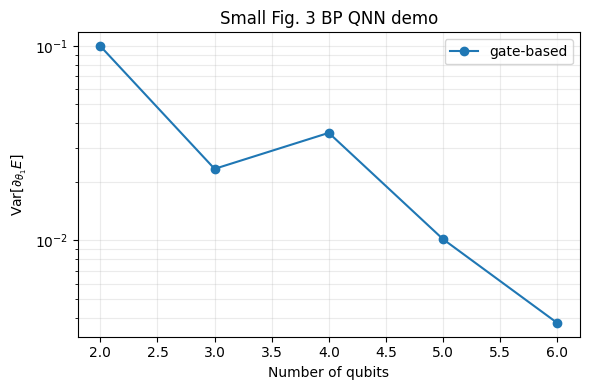

In [16]:
figure, axis = plt.subplots(figsize=(6, 4))
axis.semilogy(qubit_counts, gate_variances, "o-", label="gate-based")
axis.set_xlabel("Number of qubits")
axis.set_ylabel(r"$\operatorname{Var}[\partial_{\theta_1} E]$")
axis.set_title("Small Fig. 3 BP QNN demo")
axis.grid(True, which="both", alpha=0.25)
axis.legend()
figure.tight_layout()

## 2. Photonic BP QNN analogue

The photonic helper builds a dual-rail input state and a universal interferometer, then computes the same kind of gradient-variance statistic with a fidelity-style loss. We use arcsine initialization and only 2–4 logical qubits so the cell is practical on a laptop.

In [17]:
photonic_spaces = ["fock", "unbunched", "dual_rail"]
photonic_variances = {}
photonic_config = {"dtype": "float32"}

for computation_space in photonic_spaces:
    variances = [
        sample_photonic_variance(
            number_of_qubits=number_of_qubits,
            computation_space=computation_space,
            initialization="arcsin",
            samples=samples,
            cfg=photonic_config,
        )
        for number_of_qubits in qubit_counts
    ]
    photonic_variances[computation_space] = variances
    print(f"{computation_space}: {[f'{value:.3e}' for value in variances]}")

fock: ['9.605e-03', '3.409e-03', '1.484e-03', '7.733e-04', '4.345e-04']
unbunched: ['1.719e-02', '7.763e-03', '3.209e-03', '1.484e-03', '8.862e-04']
dual_rail: ['2.067e-02', '1.504e-02', '7.717e-03', '5.643e-03', '3.432e-03']


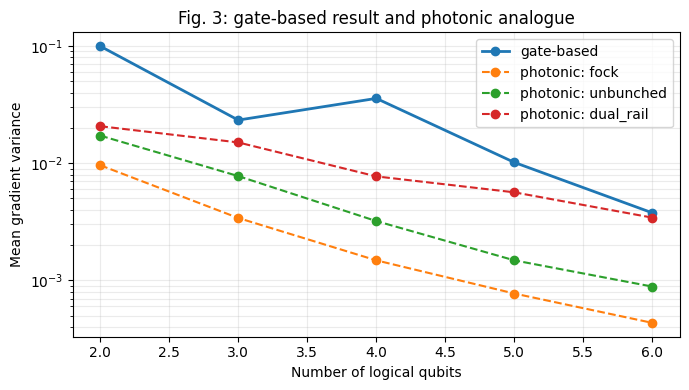

In [18]:
figure, axis = plt.subplots(figsize=(7, 4))
axis.semilogy(qubit_counts, gate_variances, "o-", linewidth=2, label="gate-based")
for computation_space, variances in photonic_variances.items():
    axis.semilogy(qubit_counts, variances, "o--", label=f"photonic: {computation_space}")
axis.set_xlabel("Number of logical qubits")
axis.set_ylabel("Mean gradient variance")
axis.set_title("Fig. 3: gate-based result and photonic analogue")
axis.grid(True, which="both", alpha=0.25)
axis.legend()
figure.tight_layout()

With only three qubit counts and four random samples, this is a teaching demo rather than a statistically precise reproduction. Increase `qubit_counts` and `samples` for a closer reproduction; the full settings are in `configs/fig3_gb.json` and `configs/fig3_merlin.json`. The gate-based and photonic curves should be compared qualitatively because their state spaces, objectives, and gradient vectors differ.